In [ ]:
# [Librerías importadas]

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import rioxarray
from shapely.geometry import Point
import warnings
import tempfile
warnings.filterwarnings("ignore")

In [43]:
import geopandas as gpd
import rioxarray
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import mapclassify
from rasterstats import zonal_stats
import tempfile
import os

def mapa_climatico_anual(
    rutas: dict,
    shapefile_path: str,
    variable_nc: str,
    nombre_columna: str,
    etiqueta_colorbar: str,
    titulo_general: str,
    unidad_conversion=None,
    cmap: str = "YlGnBu",
    vecinos: int = 3,
    guardar_raster: bool = False,
    carpeta_salida: str = None
):
    """
    Genera mapas anuales promedio por municipio para una variable climática.
    Aplica clasificación por cuantiles (k=5) y rellena valores faltantes
    con el promedio de municipios vecinos.
    """

    # ------------------------------------------------------------
    # 1️⃣ Cargar shapefile base
    # ------------------------------------------------------------
    gdf_base = gpd.read_file(shapefile_path, encoding="utf-8")
    if "mpio_cnmbr" in gdf_base.columns:
        gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
    gdf_base = gdf_base[gdf_base['dpto_cnmbr'].str.upper() == 'ATLÁNTICO']

    resultados = []

    # ------------------------------------------------------------
    # 2️⃣ Crear figura
    # ------------------------------------------------------------
    n = len(rutas)
    filas = 2
    columnas = int(np.ceil(n / filas))
    fig, axes = plt.subplots(filas, columnas, figsize=(4 * columnas, 4 * filas))
    axes = axes.flatten()

    # ------------------------------------------------------------
    # 3️⃣ Procesar cada año
    # ------------------------------------------------------------
    for i, (anio, ruta) in enumerate(rutas.items()):
        print(f"Procesando {anio}...")

        ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")
        var = ds[variable_nc].rio.write_crs("EPSG:4326")

        # --- Conversión automática ---
        data = var
        if "Temperature" in variable_nc:
            data = data - 273.15  # Kelvin → °C
            if cmap == "YlGnBu":  # por defecto cambiar a algo más apropiado
                cmap = "RdYlBu_r"
        elif "Humidity" in variable_nc or "Humedad" in variable_nc:
            if data.max() <= 1:
                data = data * 100  # 0–1 → %
            cmap = "YlGnBu"

        # --- Conversión personalizada si se define ---
        if unidad_conversion is not None:
            data = unidad_conversion(data)

        # --- Promedio anual ---
        promedio_anual = data.mean(dim="time", skipna=True)

        # --- Guardar raster temporal ---
        if guardar_raster and carpeta_salida:
            os.makedirs(carpeta_salida, exist_ok=True)
            raster_out = os.path.join(carpeta_salida, f"{nombre_columna}_{anio}.tif")
            promedio_anual.rio.to_raster(raster_out)
        else:
            tmp = tempfile.NamedTemporaryFile(suffix=".tif", delete=False)
            raster_out = tmp.name
            promedio_anual.rio.to_raster(raster_out)
            tmp.close()

        # --- Estadísticas zonales ---
        gdf = gdf_base.copy()
        stats = zonal_stats(gdf, raster_out, stats="mean", nodata=np.nan)
        gdf[nombre_columna] = [s["mean"] for s in stats]

        # --- Rellenar faltantes ---
        gdf["centroide"] = gdf.geometry.centroid
        gdf_con_datos = gdf.dropna(subset=[nombre_columna])
        gdf_sin_datos = gdf[gdf[nombre_columna].isna()]

        for idx, row in gdf_sin_datos.iterrows():
            gdf_con_datos["dist"] = gdf_con_datos["centroide"].distance(row["centroide"])
            vecinos_cercanos = gdf_con_datos.nsmallest(vecinos, "dist")
            gdf.at[idx, nombre_columna] = vecinos_cercanos[nombre_columna].mean()

        gdf.drop(columns="centroide", inplace=True)

        # --- Guardar resultado para CSV final ---
        gdf["año"] = anio
        resultados.append(gdf[["municipio", "año", nombre_columna]])

        # --- Graficar ---
        ax = axes[i]
        gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
        gdf.plot(
            column=nombre_columna,
            cmap=cmap,
            scheme="Quantiles",
            k=5,
            edgecolor="black",
            linewidth=0.5,
            ax=ax,
            missing_kwds={"color": "white", "hatch": "///", "label": "Sin datos"}
        )

        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=plt.Normalize(vmin=gdf[nombre_columna].min(), vmax=gdf[nombre_columna].max())
        )
        sm._A = []
        cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
        cbar.set_label(etiqueta_colorbar, fontsize=9)

        ax.set_title(f"{anio}", fontsize=11)
        ax.axis("off")

        # Limpiar archivo temporal
        if not guardar_raster:
            os.remove(raster_out)

    # ------------------------------------------------------------
    # 4️⃣ Resultado final y visualización
    # ------------------------------------------------------------
    plt.suptitle(titulo_general, fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()




## Precipitación

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...
Procesando 2021...
Procesando 2022...
Procesando 2023...


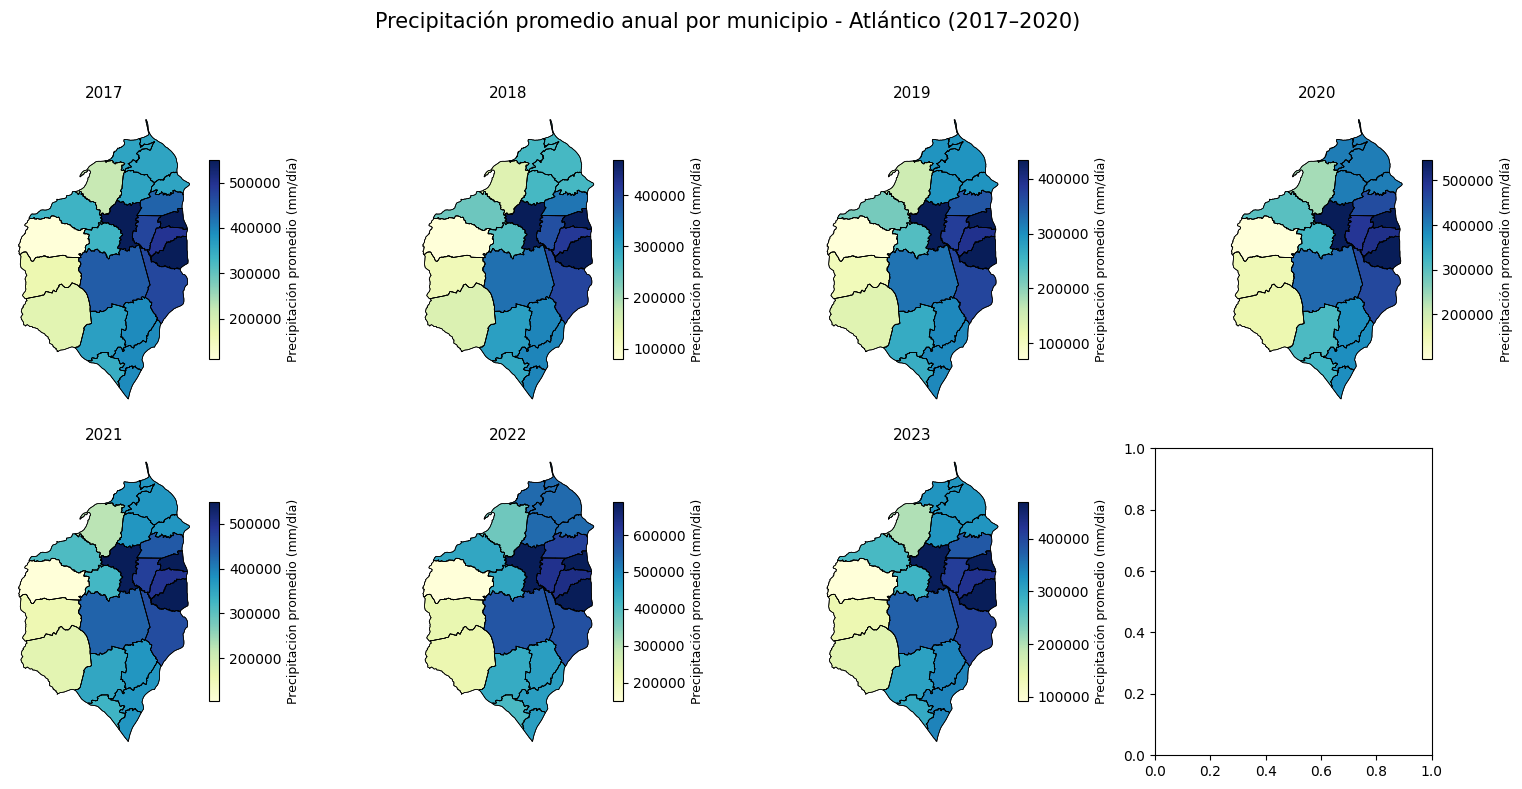

In [14]:
rutas_prec = {
   
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019",
    2020: r"C:\Dengue\Datos Clima\precipitacion_atl_2020",
    2021: r"C:\Dengue\Datos Clima\precipitacion_atl_2021",
    2022: r"C:\Dengue\Datos Clima\precipitacion_atl_2022",
    2023: r"C:\Dengue\Datos Clima\precipitacion_atl_2023"
}


mapa_climatico_anual(
    rutas=rutas_prec,
    shapefile_path="Datos adjuntos\Mapas_municipio\MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Precipitation_Flux",
    nombre_columna="precipitacion_promedio",
    etiqueta_colorbar="Precipitación promedio (mm/día)",
    titulo_general="Precipitación promedio anual por municipio - Atlántico (2017–2020)",
    unidad_conversion=86400,
    carpeta_salida=r"C:\Dengue\Datos Clima\figs"
)


## Humedad Relativa

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...
Procesando 2021...
Procesando 2022...
Procesando 2023...


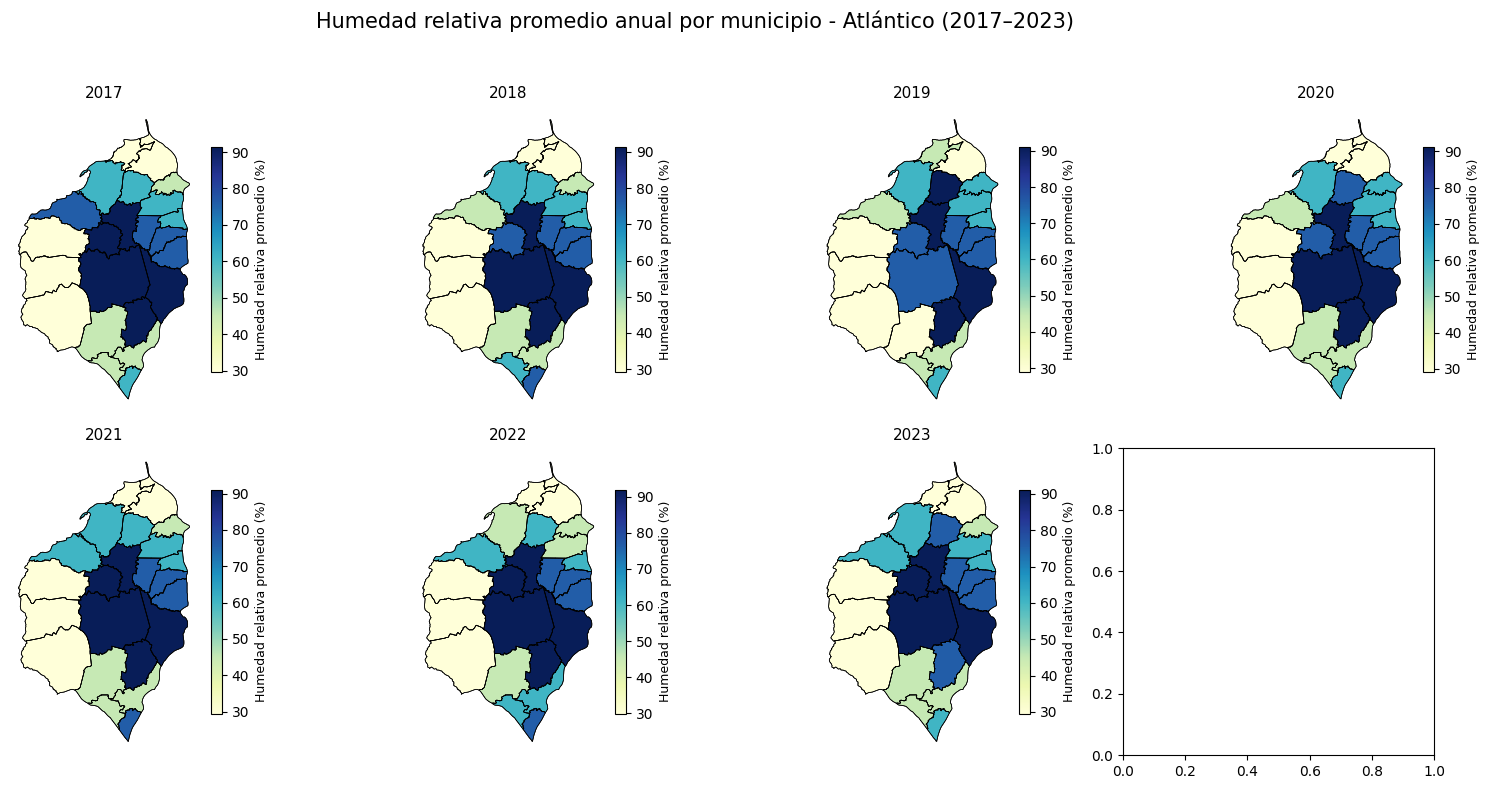

In [39]:
rutas_hum = {
    2017: r"C:\Dengue\Datos Clima\humedad_atl_2017",
    2018: r"C:\Dengue\Datos Clima\humedad_atl_2018",
    2019: r"C:\Dengue\Datos Clima\humedad_atl_2019",
    2020: r"C:\Dengue\Datos Clima\humedad_atl_2020",
    2021: r"C:\Dengue\Datos Clima\humedad_atl_2021",
    2022: r"C:\Dengue\Datos Clima\humedad_atl_2022",
    2023: r"C:\Dengue\Datos Clima\humedad_atl_2023"
}

mapa_climatico_anual(
    rutas=rutas_hum,
    shapefile_path="Datos adjuntos\Mapas_municipio\MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Relative_Humidity_2m_06h",
    nombre_columna="humedad_promedio",
    etiqueta_colorbar="Humedad relativa promedio (%)",
    titulo_general="Humedad relativa promedio anual por municipio - Atlántico (2017–2023)"
)


## Temperatura

### Maxima

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...
Procesando 2021...
Procesando 2022...
Procesando 2023...


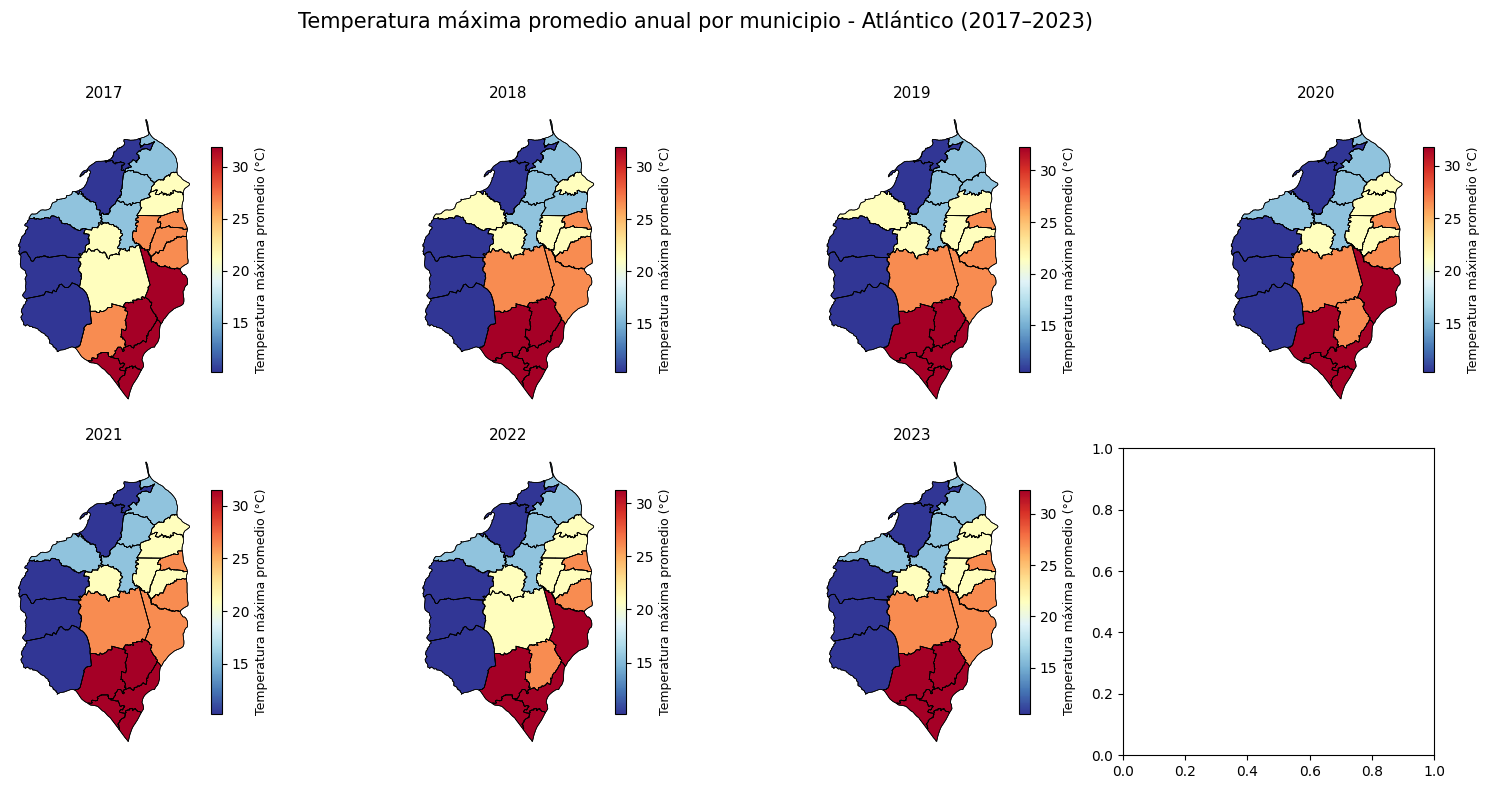

In [44]:
rutas_temp_max = {
    2017: r"C:\Dengue\Datos Clima\temp_max_atl_2017",
    2018: r"C:\Dengue\Datos Clima\temp_max_atl_2018",
    2019: r"C:\Dengue\Datos Clima\temp_max_atl_2019",
    2020: r"C:\Dengue\Datos Clima\temp_max_atl_2020",
    2021: r"C:\Dengue\Datos Clima\temp_max_atl_2021",
    2022: r"C:\Dengue\Datos Clima\temp_max_atl_2022",
    2023: r"C:\Dengue\Datos Clima\temp_max_atl_2023"
}

mapa_climatico_anual(
    rutas=rutas_temp_max,
    shapefile_path="Datos adjuntos\Mapas_municipio\MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Max_24h",
    nombre_columna="temp_max_promedio",
    etiqueta_colorbar="Temperatura máxima promedio (°C)",
    titulo_general="Temperatura máxima promedio anual por municipio - Atlántico (2017–2023)"
)


### Minima

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...
Procesando 2021...
Procesando 2022...
Procesando 2023...


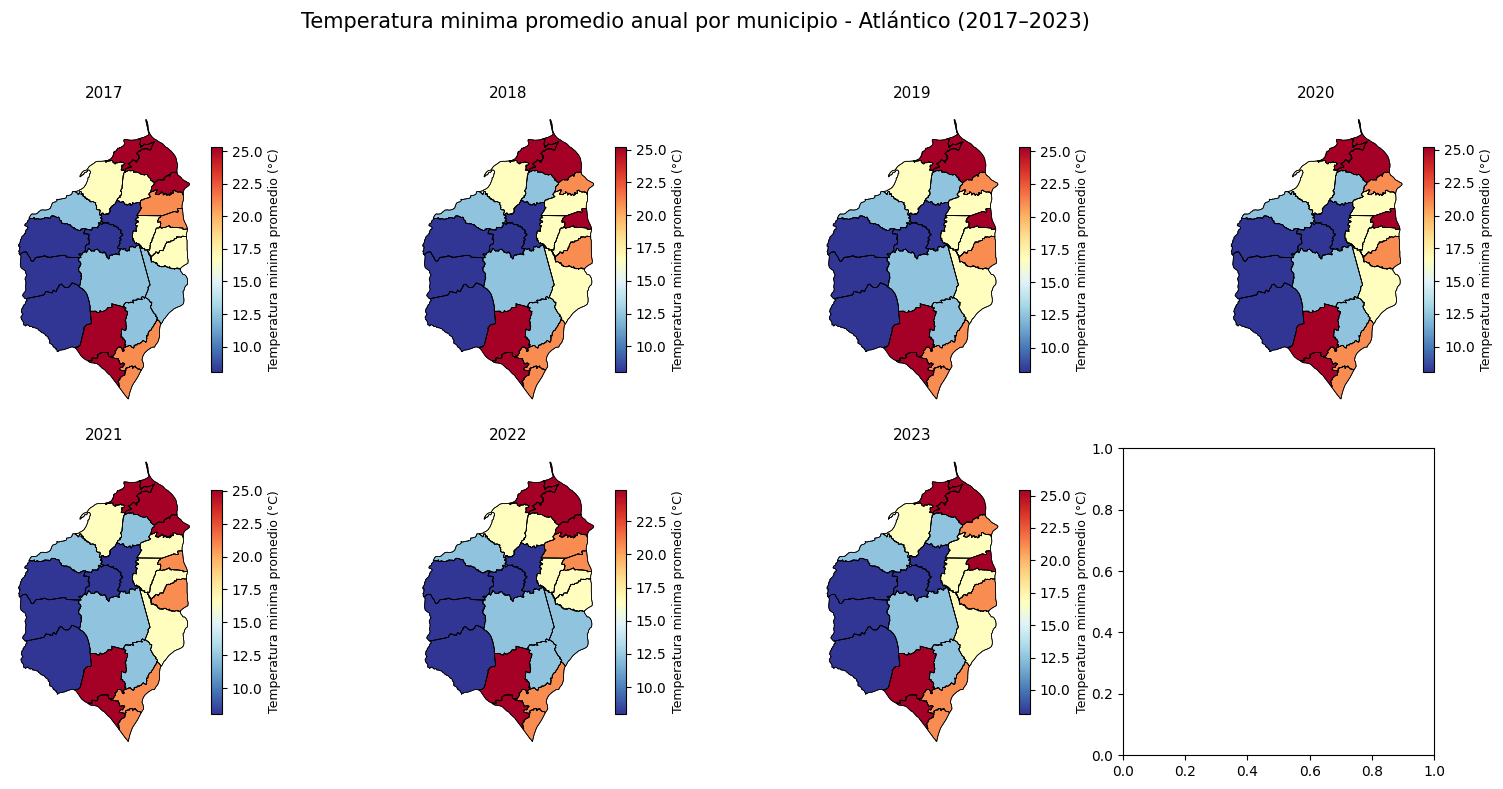

In [45]:
rutas_temp_min = {
    2017: r"C:\Dengue\Datos Clima\temp_min_atl_2017",
    2018: r"C:\Dengue\Datos Clima\temp_min_atl_2018",
    2019: r"C:\Dengue\Datos Clima\temp_min_atl_2019",
    2020: r"C:\Dengue\Datos Clima\temp_min_atl_2020",
    2021: r"C:\Dengue\Datos Clima\temp_min_atl_2021",
    2022: r"C:\Dengue\Datos Clima\temp_min_atl_2022",
    2023: r"C:\Dengue\Datos Clima\temp_min_atl_2023"
}

mapa_climatico_anual(
    rutas=rutas_temp_min,
    shapefile_path="Datos adjuntos\Mapas_municipio\MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Min_24h",
    nombre_columna="temp_min_promedio",
    etiqueta_colorbar="Temperatura minima promedio (°C)",
    titulo_general="Temperatura minima promedio anual por municipio - Atlántico (2017–2023)"
    )


## CSV

In [50]:
import geopandas as gpd
import rioxarray
import numpy as np
import pandas as pd
from rasterstats import zonal_stats
import os

def resumen_climatico_anual(
    rutas,
    shapefile_path,
    variable_nc,
    nombre_columna,
    carpeta_salida="resumenes",
    unidad_conversion=None
):
    """
    Calcula el promedio anual por municipio para cada año,
    guarda un CSV intermedio y devuelve un DataFrame.
    """

    # Crear carpeta de salida si no existe
    os.makedirs(carpeta_salida, exist_ok=True)

    gdf_base = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
    resultados = []

    for año, ruta in rutas.items():
        print(f"📆 Procesando {nombre_columna} - {año}...")

        # --- Abrir dataset ---
        ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")
        var = ds[variable_nc].rio.write_crs("EPSG:4326")

        # --- Conversión automática ---
        if "Temperature" in variable_nc:
            var = var - 273.15  # Kelvin a °C
        elif "Humidity" in variable_nc:
            if var.max() <= 1:
                var = var * 100  # 0–1 → %
        elif "Precipitation" in variable_nc and unidad_conversion is None:
            unidad_conversion = lambda x: x * 86400  # kg/m²/s → mm/día

        if unidad_conversion:
            var = unidad_conversion(var)

        # --- Promedio anual ---
        promedio_anual = var.mean(dim="time", skipna=True)

        # --- Cálculo zonal ---
        # Guardar raster temporal en archivo físico
        tmp_raster = "tmp_promedio.tif"
        promedio_anual.rio.to_raster(tmp_raster)

        # Calcular estadísticos zonales
        gdf = gdf_base.copy()
        stats = zonal_stats(gdf, tmp_raster, stats="mean", nodata=np.nan)

        # Eliminar archivo temporal
        os.remove(tmp_raster)

        gdf[nombre_columna] = [s["mean"] for s in stats]

        # --- Guardar resultado ---
        df = gdf[["mpio_cnmbr", nombre_columna]].copy()
        df["año"] = año
        resultados.append(df)

    # Combinar todos los años
    df_final = pd.concat(resultados, ignore_index=True)
    df_final.rename(columns={"mpio_cnmbr": "municipio"}, inplace=True)
    df_final = df_final.round(2)

    # Guardar CSV intermedio
    csv_path = os.path.join(carpeta_salida, f"{nombre_columna}_anual.csv")
    df_final.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"✅ Archivo guardado: {csv_path}")

    return df_final


In [51]:
# --- Humedad relativa ---
df_hum = resumen_climatico_anual(
    rutas_hum,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Relative_Humidity_2m_06h",
    nombre_columna="humedad_relativa"
)

# --- Temperatura máxima ---
df_tmax = resumen_climatico_anual(
    rutas_temp_max,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Max_24h",
    nombre_columna="temp_max"
)

# --- Temperatura mínima ---
df_tmin = resumen_climatico_anual(
    rutas_temp_min,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Temperature_Air_2m_Min_24h",
    nombre_columna="temp_min"
)

# --- Precipitación ---
df_prec = resumen_climatico_anual(
    rutas_prec,
    shapefile_path="Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp",
    variable_nc="Precipitation_Flux",
    nombre_columna="precipitacion"
)


📆 Procesando humedad_relativa - 2017...
📆 Procesando humedad_relativa - 2018...
📆 Procesando humedad_relativa - 2019...
📆 Procesando humedad_relativa - 2020...
📆 Procesando humedad_relativa - 2021...
📆 Procesando humedad_relativa - 2022...
📆 Procesando humedad_relativa - 2023...
✅ Archivo guardado: resumenes\humedad_relativa_anual.csv
📆 Procesando temp_max - 2017...
📆 Procesando temp_max - 2018...
📆 Procesando temp_max - 2019...
📆 Procesando temp_max - 2020...
📆 Procesando temp_max - 2021...
📆 Procesando temp_max - 2022...
📆 Procesando temp_max - 2023...
✅ Archivo guardado: resumenes\temp_max_anual.csv
📆 Procesando temp_min - 2017...
📆 Procesando temp_min - 2018...
📆 Procesando temp_min - 2019...
📆 Procesando temp_min - 2020...
📆 Procesando temp_min - 2021...
📆 Procesando temp_min - 2022...
📆 Procesando temp_min - 2023...
✅ Archivo guardado: resumenes\temp_min_anual.csv
📆 Procesando precipitacion - 2017...
📆 Procesando precipitacion - 2018...
📆 Procesando precipitacion - 2019...
📆 Proc

In [ ]:
# Combinar por municipio y año
df_final = (
    df_hum
    .merge(df_prec, on=["municipio", "año"], how="outer")
    .merge(df_tmax, on=["municipio", "año"], how="outer")
    .merge(df_tmin, on=["municipio", "año"], how="outer")
)

# Reordenar columnas
df_final = df_final[["municipio", "año", "humedad_relativa", "precipitacion", "temp_max", "temp_min"]]

# Guardar CSV final
df_final.to_csv("resumen_climatico_atlantico_2017_2023.csv", index=False, encoding="utf-8-sig")
print("✅ Archivo final generado: resumen_climatico_atlantico_2017_2023.csv")


## Disntacia al Río mas cercano